In [7]:
# social_Network_Ads.csv

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv('Social_Network_Ads.csv')

In [10]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0


In [11]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   User ID          400 non-null    int64  
 1   Gender           400 non-null    object 
 2   Age              400 non-null    float64
 3   EstimatedSalary  400 non-null    float64
 4   Purchased        400 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 15.8+ KB


In [13]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

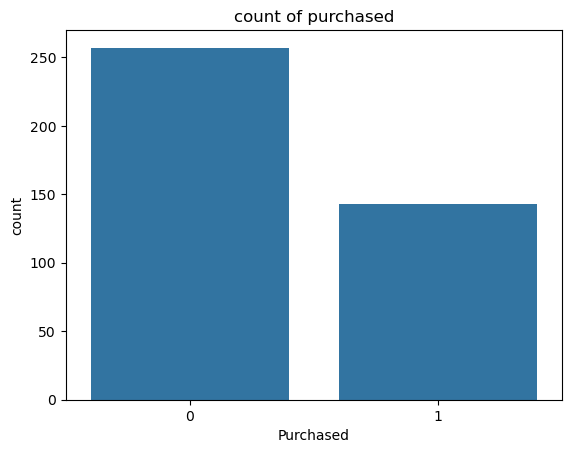

In [14]:
sns.countplot(x='Purchased',data = df)
plt.title('count of purchased')
plt.show()

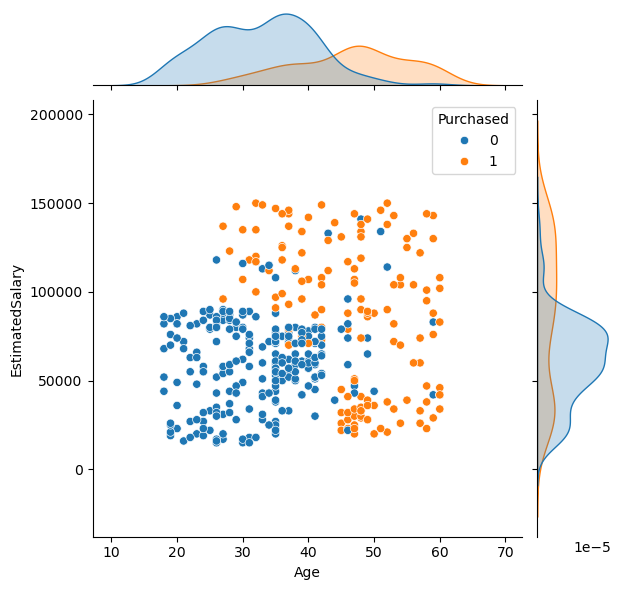

In [15]:
sns.jointplot(x = 'Age',y = 'EstimatedSalary', data = df ,hue = 'Purchased');

In [16]:
# seperate input and output
# check target distribution 
# cross validation and feature scaling

In [17]:
x = df[['Age','EstimatedSalary']]
y = df['Purchased']

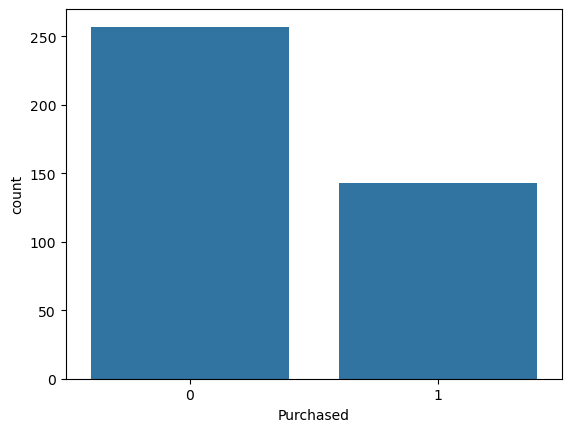

Purchased
0    257
1    143
Name: count, dtype: int64


In [18]:
sns.countplot(x = 'Purchased',data=df)
plt.show()
print(df['Purchased'].value_counts())

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.25,random_state = 42)

In [21]:
# feature scaling part

In [22]:
from sklearn.preprocessing import MinMaxScaler
sca = MinMaxScaler() 

In [23]:

x_train_scaled = sca.fit_transform(x_train)

In [24]:
x_test_scaled = sca.transform(x_test)

In [25]:
# build the random forest model

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
rf = RandomForestClassifier(random_state = 0 , n_estimators = 50)

In [28]:
rf.fit(x_train_scaled,y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
y_pred = rf.predict(x_test_scaled)

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report, accuracy_score

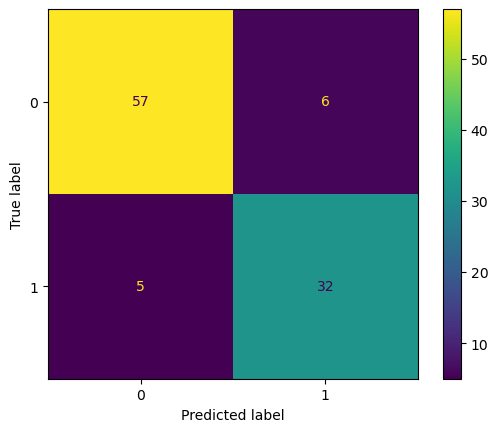

In [31]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred);

In [32]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.90      0.91        63
           1       0.84      0.86      0.85        37

    accuracy                           0.89       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.89      0.89      0.89       100



In [33]:
rf.feature_importances_

array([0.48274352, 0.51725648])

In [34]:
rf.estimators_;

In [35]:
# Bagging of KNN

In [36]:
# check the accuracy using individual knn and compare with bagging of knn

In [37]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [38]:
y_pred = knn.predict(x_test_scaled)
accuracy_score(y_test, y_pred)

0.93

In [39]:
# bagging

In [40]:
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(KNeighborsClassifier(n_neighbors=5),
                        random_state= 0, n_estimators= 50)

In [41]:
bag.fit(x_train_scaled, y_train)

,estimator,KNeighborsClassifier()
,n_estimators,50
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,0
,verbose,0


In [42]:
y_pred = bag.predict(x_test_scaled)
accuracy_score(y_test, y_pred)


0.93